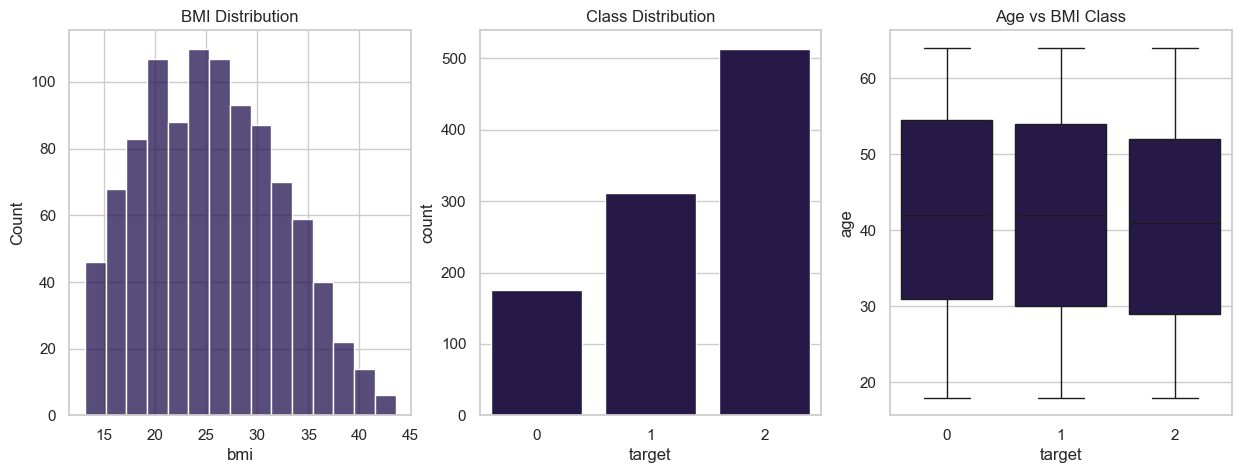

d:\Python\.venv\Lib\site-packages\keras\src\layers\reshaping\reshape.py:38: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step 


d:\Python\.venv\Lib\site-packages\keras\src\layers\reshaping\reshape.py:38: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step


d:\Python\.venv\Lib\site-packages\keras\src\layers\reshaping\reshape.py:38: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
                     Accuracy    MAE    MSE      RMSE
Logistic Regression     0.985  0.015  0.015  0.122474
Random Forest           0.975  0.025  0.025  0.158114
SVM                     0.970  0.030  0.030  0.173205
KNN                     0.925  0.075  0.075  0.273861
Decision Tree           0.935  0.065  0.065  0.254951
CNN                     0.930  0.070  0.070  0.264575
RNN                     0.930  0.070  0.070  0.264575
LSTM                    0.885  0.115  0.115  0.339116
Best model: Logistic Regression
Accuracy: 0.9850


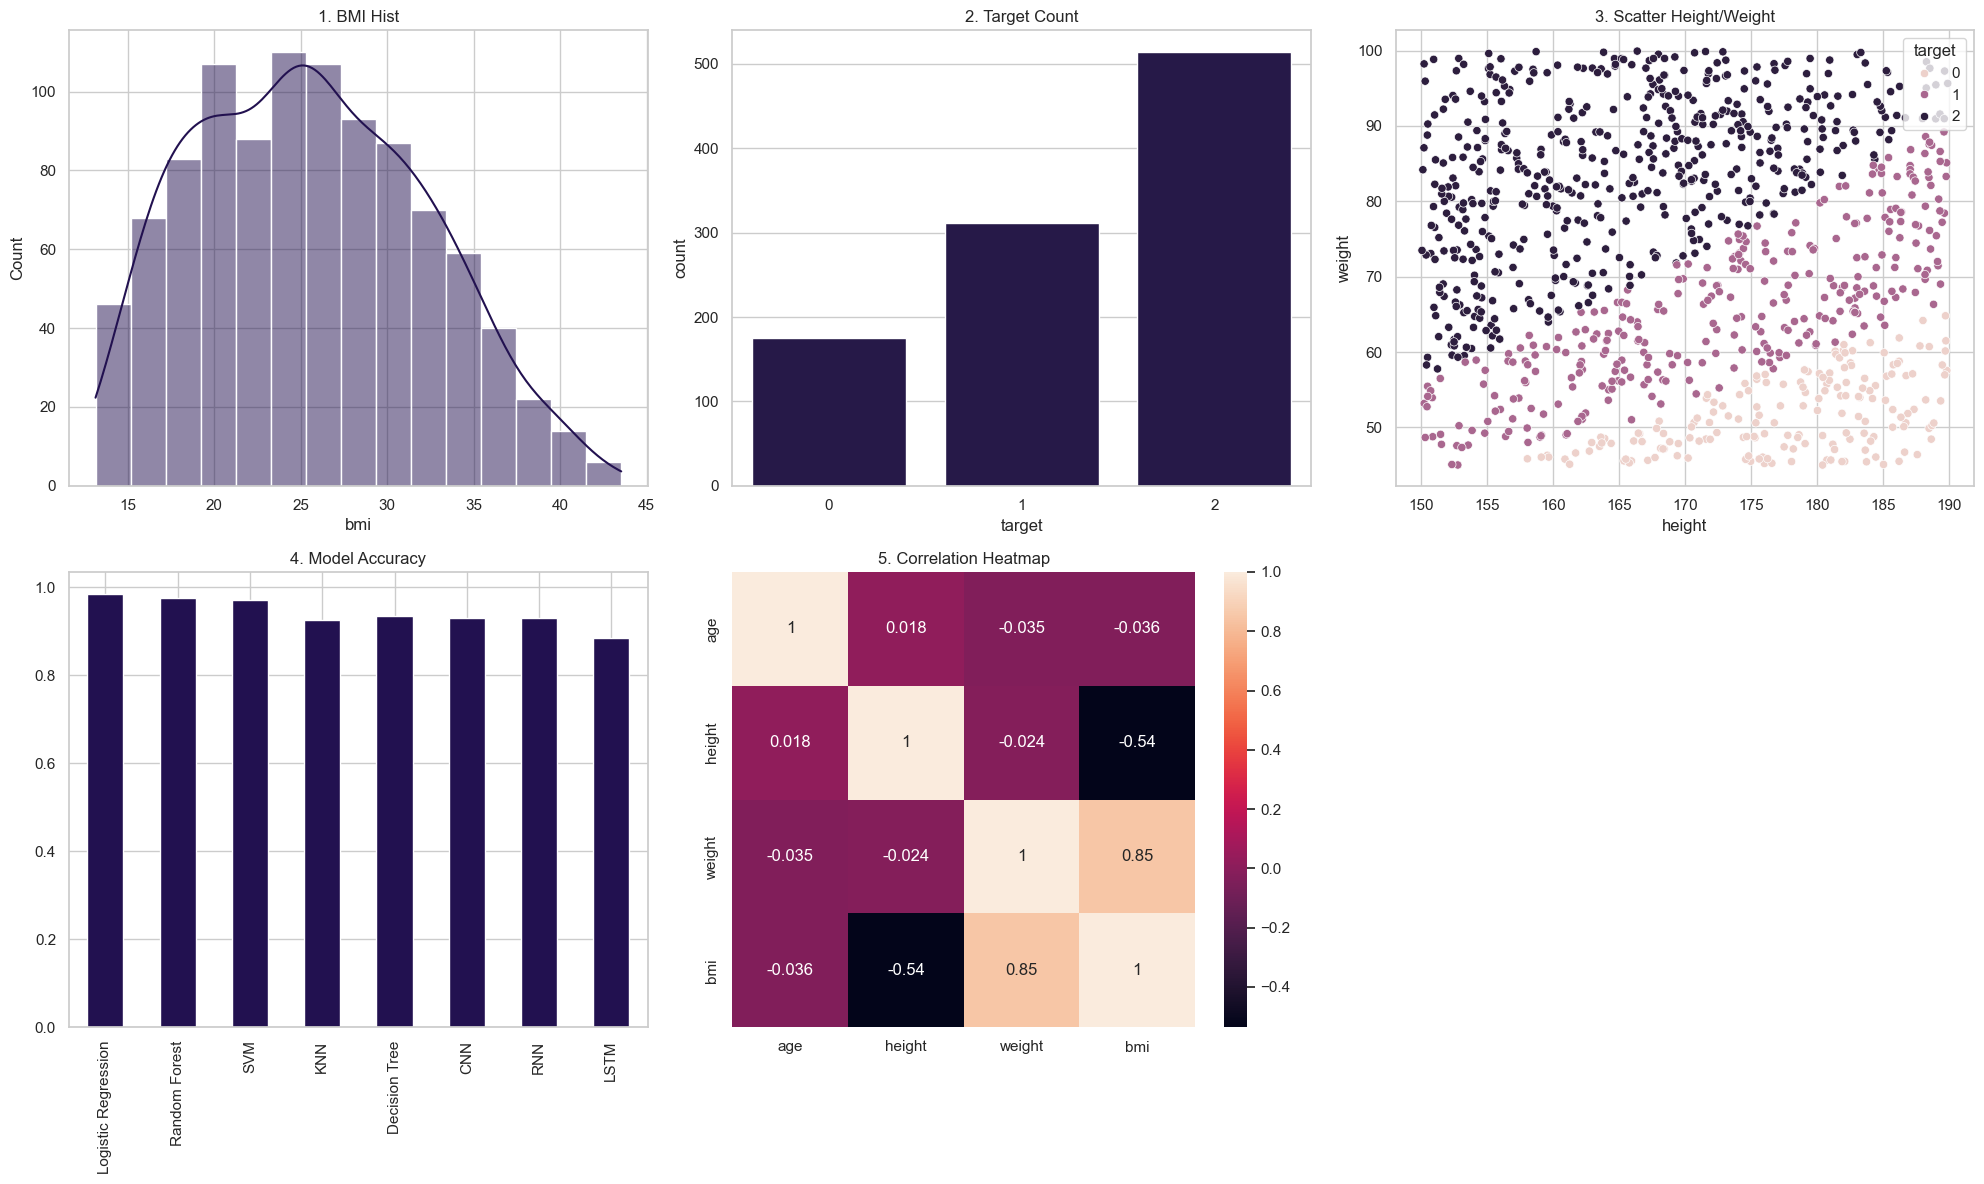

* Running on local URL:  http://127.0.0.1:7882
* Running on public URL: https://69e79195ec115e60b9.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


In [26]:
# NAME: Nguyễn Tiến Đạt - B23DCCN139
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import json
import os
import gradio as gr
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, mean_absolute_error, mean_squared_error
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, LSTM, SimpleRNN, Flatten, Dropout

# Tạo thư mục lưu trữ nếu chưa có
if not os.path.exists('C:\\DATA'):
    os.makedirs('C:\\DATA')

# a. Build dataset
np.random.seed(42)
jobs_list = ['Engineer', 'Teacher', 'Doctor', 'Artist', 'Student']
data = {
    'job': np.random.choice(jobs_list, 1000),
    'age': np.random.randint(18, 65, 1000),
    'height': np.random.uniform(150, 190, 1000),
    'weight': np.random.uniform(45, 100, 1000)
}
df = pd.DataFrame(data)

df['bmi'] = df['weight'] / ((df['height']/100)**2)
def classify_bmi(bmi):
    if bmi < 18.5: return 0 # Underweight
    elif bmi < 25: return 1  # Normal
    else: return 2           # Overweight

df['target'] = df['bmi'].apply(classify_bmi)
df.to_csv('C:\\DATA\\data_4.1.csv', index=False)

# b. Show distribution (3 types) 
plt.figure(figsize=(15, 5))
plt.subplot(1, 3, 1); sns.histplot(df['bmi']); plt.title('BMI Distribution')
plt.subplot(1, 3, 2); sns.countplot(x='target', data=df); plt.title('Class Distribution')
plt.subplot(1, 3, 3); sns.boxplot(x='target', y='age', data=df); plt.title('Age vs BMI Class')
plt.show()

# Tiền xử lý dữ liệu
le_job = LabelEncoder()
le_target = LabelEncoder()
df['job_encoded'] = le_job.fit_transform(df['job'])
# Khớp nhãn chữ cho phần giải mã sau này
target_names = ['Underweight', 'Normal', 'Overweight']

X = df[['job_encoded', 'age', 'height', 'weight']]
y = df['target']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# c. 5 Basic ML Models
ml_dict = {
    "Logistic Regression": LogisticRegression(),
    "Random Forest": RandomForestClassifier(),
    "SVM": SVC(),
    "KNN": KNeighborsClassifier(),
    "Decision Tree": DecisionTreeClassifier()
}

results = {}
for name, model in ml_dict.items():
    model.fit(X_train_scaled, y_train)
    y_pred = model.predict(X_test_scaled)
    results[name] = [accuracy_score(y_test, y_pred), mean_absolute_error(y_test, y_pred), 
                     mean_squared_error(y_test, y_pred), np.sqrt(mean_squared_error(y_test, y_pred))]

# d. Build CNN, RNN, LSTM
dl_models = {}
def build_dl_model(m_type):
    model = Sequential()
    model.add(tf.keras.layers.Reshape((4, 1), input_shape=(4,)))
    if m_type == 'CNN':
        model.add(tf.keras.layers.Conv1D(32, 2, activation='relu'))
        model.add(Flatten())
    elif m_type == 'RNN':
        model.add(SimpleRNN(32, activation='relu'))
    elif m_type == 'LSTM':
        model.add(LSTM(32, activation='relu'))
    
    model.add(Dense(64, activation='relu'))
    model.add(Dropout(0.2))
    model.add(Dense(3, activation='softmax'))
    model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    return model

for m_name in ['CNN', 'RNN', 'LSTM']:
    m = build_dl_model(m_name)
    m.fit(X_train_scaled, y_train, epochs=5, verbose=0) # Epoch thấp để chạy nhanh
    dl_models[m_name] = m
    y_pred = np.argmax(m.predict(X_test_scaled), axis=1)
    results[m_name] = [accuracy_score(y_test, y_pred), mean_absolute_error(y_test, y_pred),
                       mean_squared_error(y_test, y_pred), np.sqrt(mean_squared_error(y_test, y_pred))]

# e. Compare and evaluate
metrics_df = pd.DataFrame(results, index=['Accuracy', 'MAE', 'MSE', 'RMSE']).T
print(metrics_df)
# Tìm model tốt nhất dựa trên Accuracy
best_model_name = metrics_df['Accuracy'].idxmax()
best_accuracy = metrics_df.loc[best_model_name, 'Accuracy']
print(f"Best model: {best_model_name}")
print(f"Accuracy: {best_accuracy:.4f}")

# f. Visualize >= 5 types
sns.set_theme(style="whitegrid", palette="magma") 
plt.figure(figsize=(20, 12))
plt.subplot(2, 3, 1); sns.histplot(df['bmi'], kde=True); plt.title('1. BMI Hist')
plt.subplot(2, 3, 2); sns.countplot(x='target', data=df); plt.title('2. Target Count')
plt.subplot(2, 3, 3); sns.scatterplot(x='height', y='weight', hue='target', data=df); plt.title('3. Scatter Height/Weight')
plt.subplot(2, 3, 4); metrics_df['Accuracy'].plot(kind='bar'); plt.title('4. Model Accuracy')
plt.subplot(2, 3, 5); sns.heatmap(df[['age','height','weight','bmi']].corr(), annot=True); plt.title('5. Correlation Heatmap')
plt.tight_layout()
plt.show()


# g. Knowledge Base and Deploy
kb_data = {
    "Underweight": "Gain weight with protein-rich diet and strength training.",
    "Normal": "Excellent! Maintain your current lifestyle and stay active.",
    "Overweight": "Focus on calorie deficit, reduce sugar, and increase cardio."
}
with open("C:/DATA/kb_healthGuide.json", "w", encoding='utf-8') as f:
    json.dump(kb_data, f, ensure_ascii=False)

def health_advisor_web(job, age, height, weight):
    # Encoding job
    job_enc = le_job.transform([job])[0]
    input_data = scaler.transform([[job_enc, age, height, weight]])
    best_model_name = metrics_df['Accuracy'].idxmax()
    if best_model_name in dl_models:
        pred_raw = dl_models[best_model_name].predict(input_data.reshape(1, 4, 1))
        pred_idx = np.argmax(pred_raw, axis=1)[0]
    else:
        pred_idx = ml_dict[best_model_name].predict(input_data)[0]
    label_str = target_names[pred_idx]
    advice = kb_data.get(label_str, "Stay healthy!")
    return f"{label_str}", f"{advice}"

web_app = gr.Interface(
    fn=health_advisor_web,
    inputs=[
        gr.Dropdown(choices=jobs_list, label="Jobs"),
        gr.Number(label="Age", value=25),
        gr.Number(label="Height (cm)", value=170),
        gr.Number(label="Weight (kg)", value=60)
    ],
    outputs=[gr.Textbox(label="Prediction"), gr.Textbox(label="Guide")],
    title="Health Advisor DL01"
)
web_app.launch(share=True)